# Notebook 1 — Exploração e limpeza dos dados
**Afonso Carvalho & Marcello Portugal** | ISCAC — Projeto em Ciência de Dados

Este notebook percorre todas as etapas de preparação do dataset Wine Quality:
carregamento dos ficheiros originais, inspeção inicial, análise univariada e bivariada,
tratamento de outliers, engenharia de atributos e exportação do dataset limpo para modelação.

## 1. Carregamento dos dados
Os dois ficheiros CSV originais (vinhos tintos e brancos) são carregados separadamente.
Cada um contém 11 variáveis físico-químicas e uma nota de qualidade atribuída por um painel de degustadores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Unificação do dataset
Os dois conjuntos são unidos num só DataFrame. Para distinguir a origem, criamos duas variáveis:
- `type` (texto: 'red' / 'white') para leitura humana
- `is_red` (binária: 1 / 0) para uso direto nos modelos

O dataset unificado fica com 6.497 registos (1.599 tintos + 4.898 brancos).

## 3. Inspeção inicial
Verificação de tipos de dados, valores nulos e estatísticas descritivas.
O objetivo é confirmar que o dataset não tem problemas estruturais antes de avançar.

In [2]:
#Marcello Portugal

#Carregar os datasets
red_wine = pd.read_csv('/kaggle/input/datasets/marcelloportugal/wine-quality-dataset/winequality-red.csv', sep=';')
white_wine = pd.read_csv('/kaggle/input/datasets/marcelloportugal/wine-quality-dataset/winequality-white.csv', sep=';')
display(red_wine.head())
display(white_wine.head())


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Exportação do dataset unificado para CSV, para backup e possível reutilização fora do notebook.

---
# Milestone 2 — Análise exploratória e pré-processamento

In [3]:
#Marcello Portugal 

#Criar variáveis de distinção (binária e nominal) e Unificar os datasets
#Este será o dataset que iremos trabalhar
red_wine['type'] = 'red'
red_wine['is_red'] = 1

white_wine['type'] = 'white'
white_wine['is_red'] = 0

df = pd.concat([red_wine, white_wine], ignore_index=True)

#Mostra o topo (Red Wines)
display(df.head())
#Mostra o final (White Wines)
display(df.tail())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,is_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,is_red
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white,0
6496,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,white,0


## 4. Conversão de tipos
A coluna `type` é convertida para categoria. Esta conversão reduz o uso de memória
e torna explícito que se trata de uma variável nominal, não de texto livre.

In [4]:
#Marcello Portugal

#Inspeção Inicial
# Verifica tipos e se há nulos
print("Estrutura e Tipos de Dados:")
df.info()

# Gera médias, desvios e valores mínimos/máximos
print("Resumo Estatístico:")
display(df.describe())

#Verificação explícita de Integridade
print("Contagem de Valores Nulos:")
print(df.isnull().sum())

Estrutura e Tipos de Dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
 13  is_red                6497 non-null   int64  
dtypes: float64(11), int64(2), object(1)
memory u

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_red
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.246114
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


Contagem de Valores Nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
is_red                  0
dtype: int64


## 5. Distribuição da variável alvo
Contagem de vinhos por nota de qualidade. Permite verificar se o dataset é equilibrado
ou se há notas com muito poucos exemplos (o que pode dificultar a aprendizagem do modelo).

## 6. Análise univariada — histogramas e boxplots
Para cada variável físico-química, geramos um histograma (para ver a distribuição)
e um boxplot (para identificar outliers). Variáveis com muitos valores extremos
podem precisar de tratamento antes da modelação.

In [5]:
# Exportar o dataset unificado para um ficheiro CSV
df.to_csv('wine_quality_unificado.csv', index=False)

### Frequência absoluta por tipo de vinho
Contagem e percentagem de vinhos tintos vs brancos no dataset.

## 7. Análise bivariada — correlações
Matriz de correlação de Pearson entre todas as variáveis numéricas.
Serve para identificar quais variáveis têm relação linear com a qualidade
e quais são redundantes entre si (colinearidade).

In [6]:
#MILESTONE2

### Scatter plots: cada variável vs qualidade
Gráficos de dispersão com linha de tendência para cada uma das 11 propriedades químicas.
Permitem visualizar a direção e a força da relação com a nota de qualidade.

### Coeficientes de correlação com a qualidade
Valores numéricos de correlação (r) ordenados, para complementar os gráficos anteriores.

In [7]:
#MILESTONE 2 

#Marcello Portugal e Afonso Carvalho

# Converter explicitamente a coluna 'type' para category
df['type'] = df['type'].astype('category')

# Verificar a alteração
print(df.dtypes)

fixed acidity            float64
volatile acidity         float64
citric acid              float64
residual sugar           float64
chlorides                float64
free sulfur dioxide      float64
total sulfur dioxide     float64
density                  float64
pH                       float64
sulphates                float64
alcohol                  float64
quality                    int64
type                    category
is_red                     int64
dtype: object


### Colinearidade entre variáveis
Análise de pares de variáveis que se correlacionam fortemente entre si.
Colinearidade alta pode causar instabilidade nos coeficientes de modelos lineares.
Verificamos três pares com justificação química: açúcar vs densidade, álcool vs densidade, e acidez fixa vs pH.

In [8]:
#MILESTONE2
### A normalização do dataset já esta feita. A variável categórica "type" foi normalizada a partir da criação da variável binária "is_red". Na qual o valor 1 está definido para vinho tinto e 0 para vinho branco

## 8. Verificação de valores nulos
Contagem absoluta e percentual de valores em falta por coluna.
Se houver nulos, decidimos aqui como os tratar (imputação ou remoção).

## 9. Validação e conversão de tipos
Conversão forçada das colunas químicas para numérico, com `errors='coerce'`.
Se existissem valores de texto escondidos (erros de digitação), seriam convertidos em NaN.
A contagem de novos nulos serve para confirmar que os dados estão limpos.

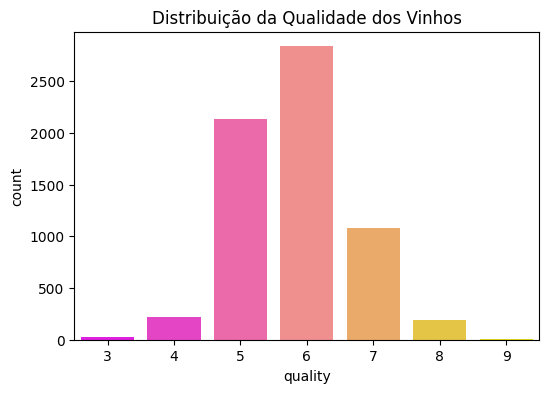

In [9]:
#MILESTONE2
#Marcello Portugal e Afonso Carvalho
#Distribuição da Variável Alvo (Quality)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='quality', hue='quality', palette='spring', legend=False)
plt.title("Distribuição da Qualidade dos Vinhos")
plt.show() 

## 10. Deteção e tratamento de outliers
### Boxplots por variável
Visualização detalhada dos outliers em cada propriedade química.

### Contagem de outliers (método IQR)
Quantificação dos valores atípicos usando o intervalo interquartil.
Um valor é considerado outlier se estiver abaixo de Q1 − 1.5×IQR ou acima de Q3 + 1.5×IQR.

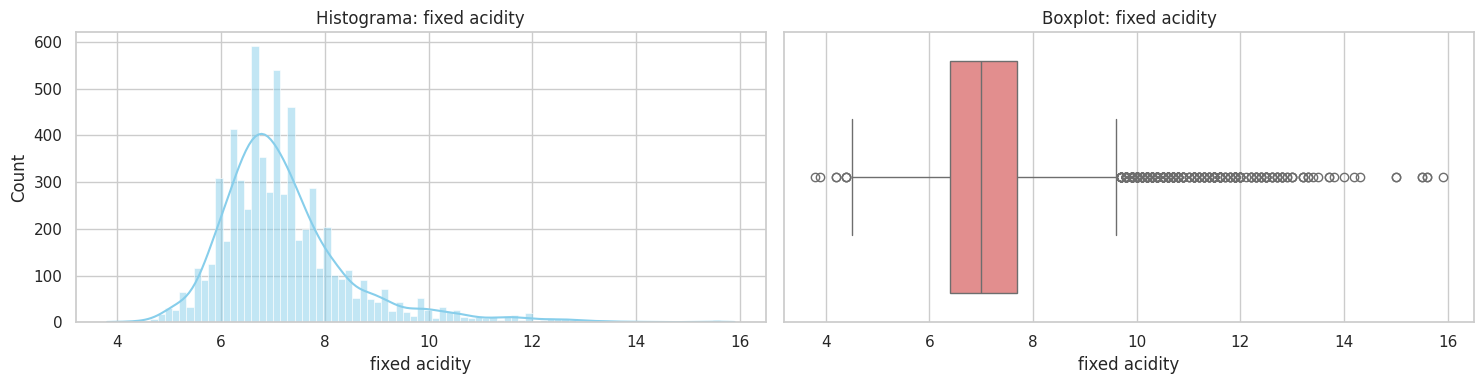

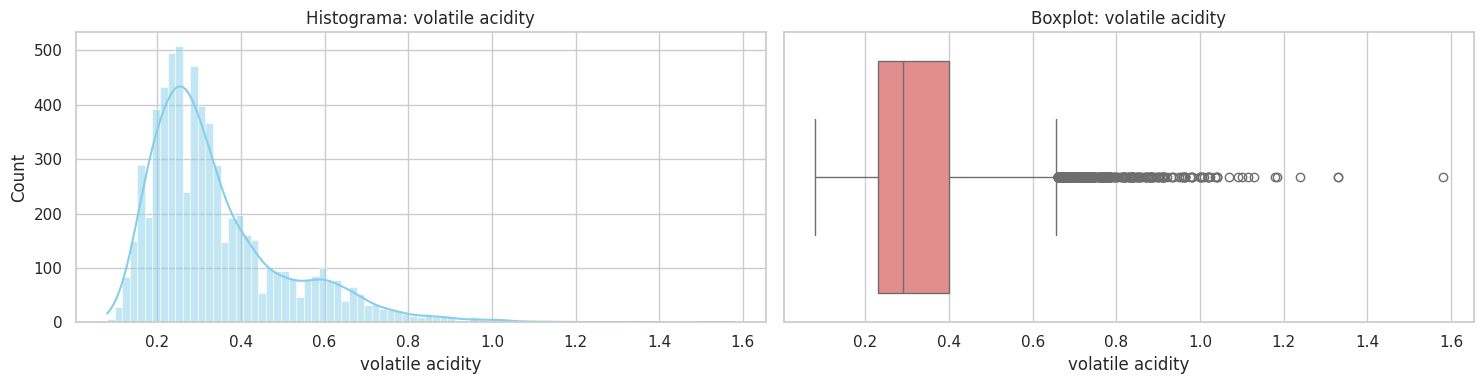

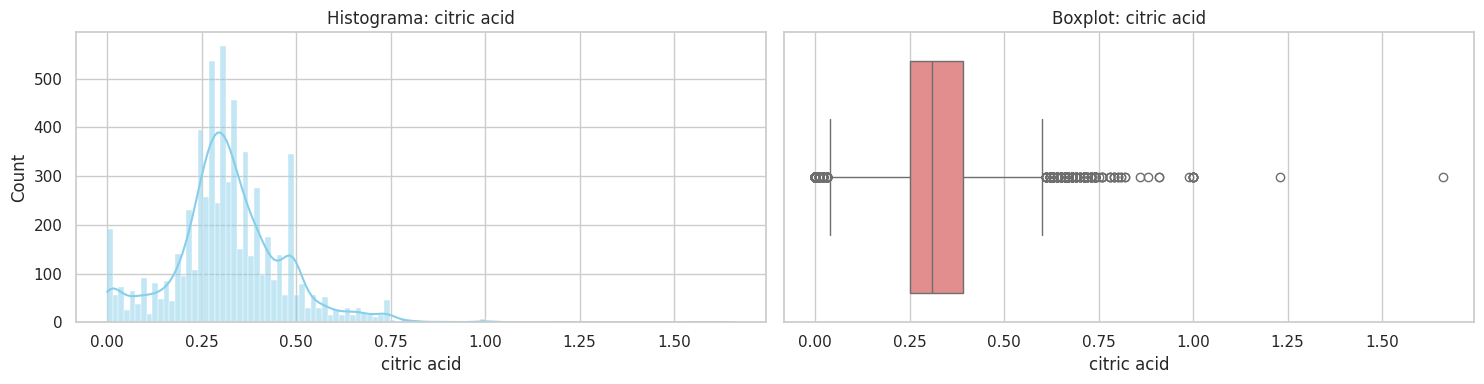

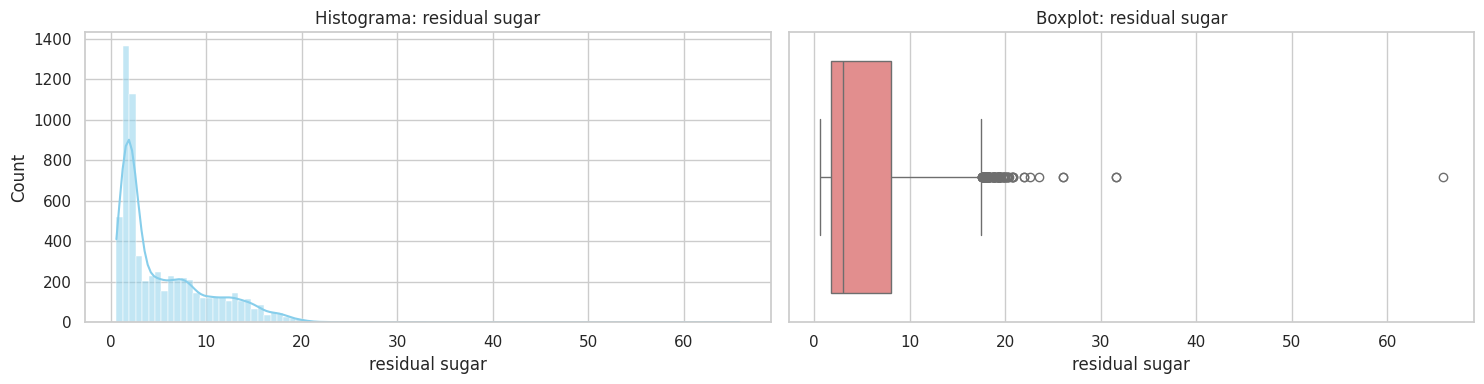

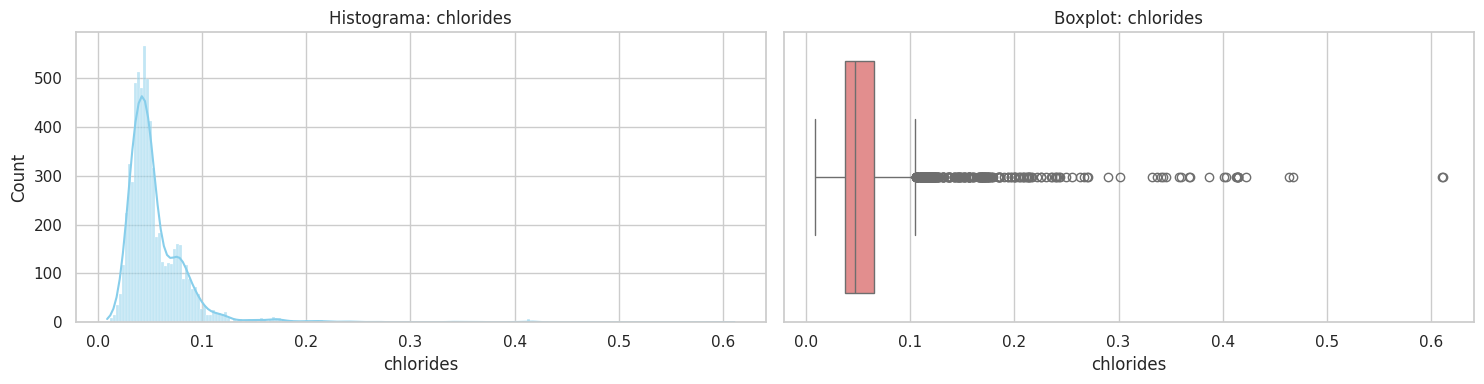

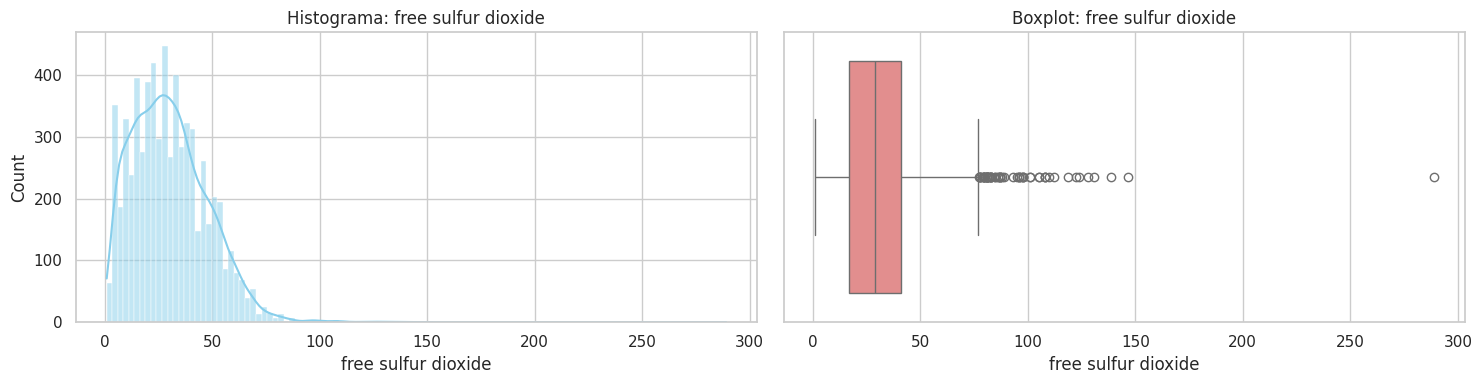

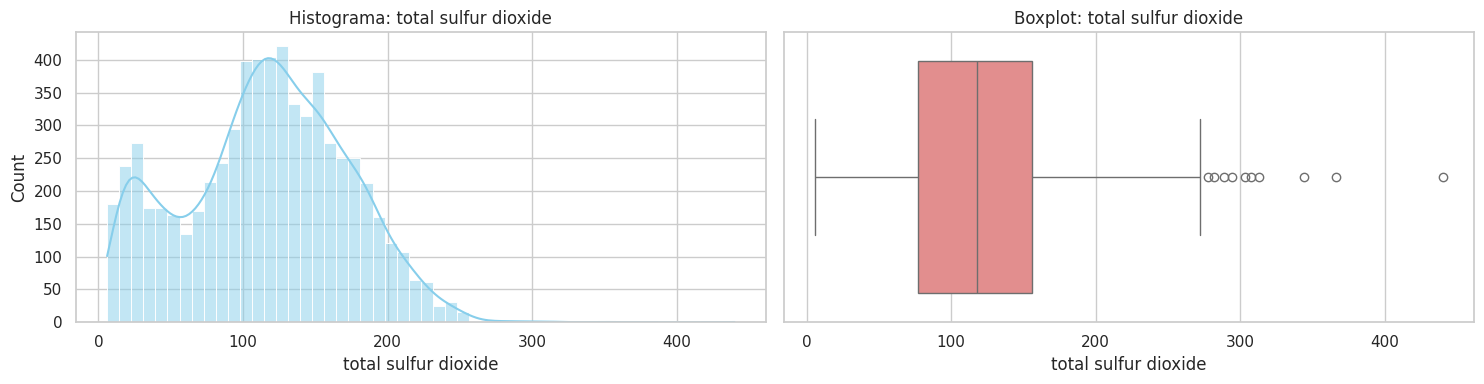

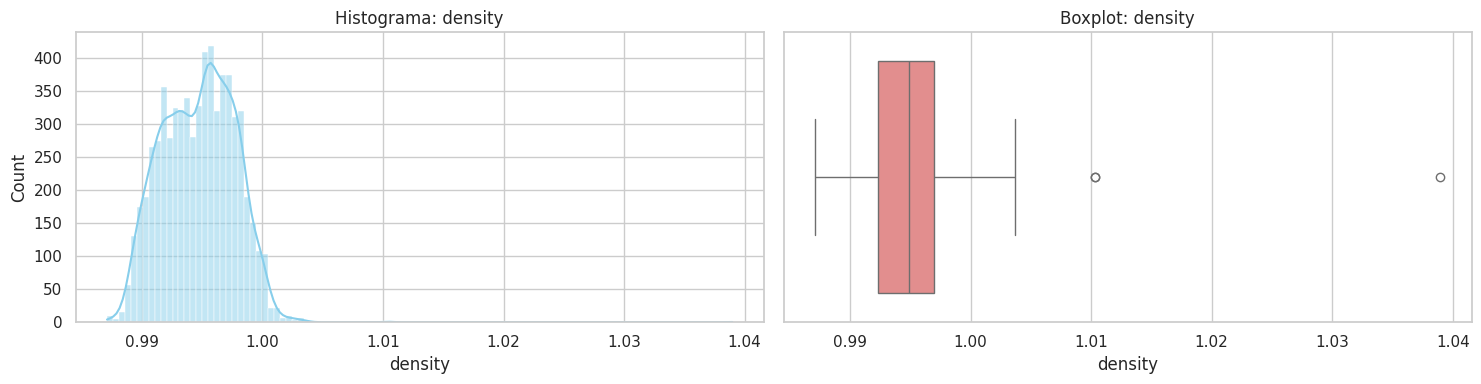

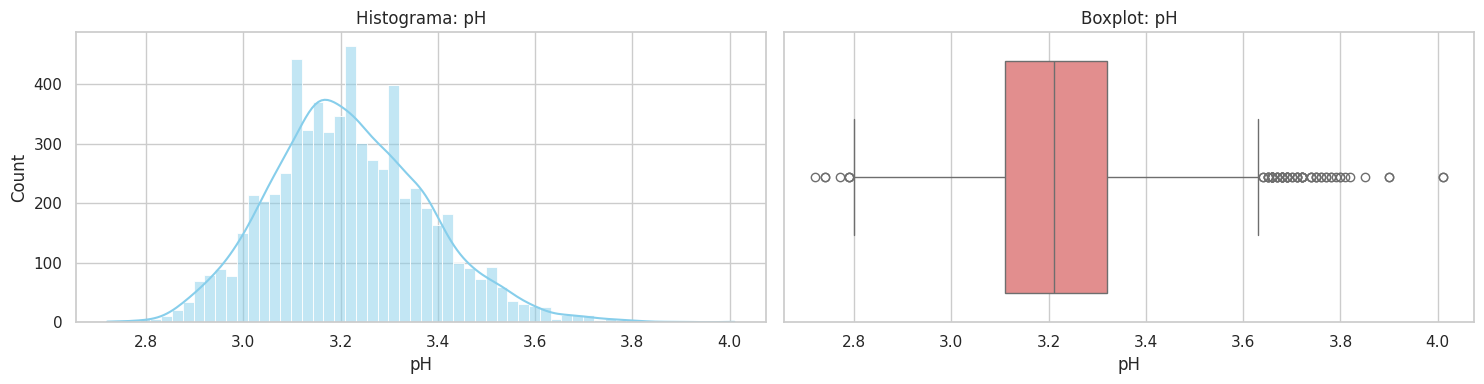

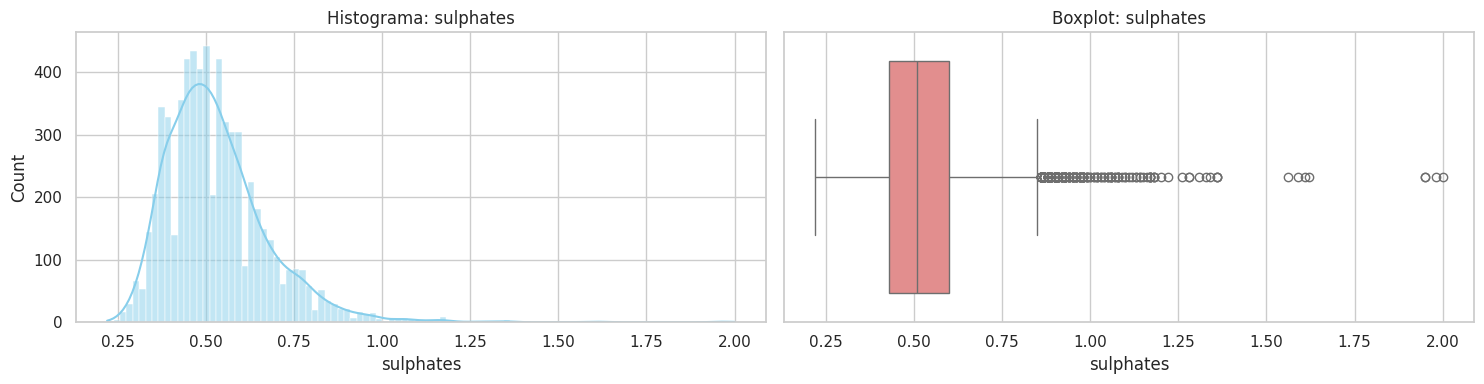

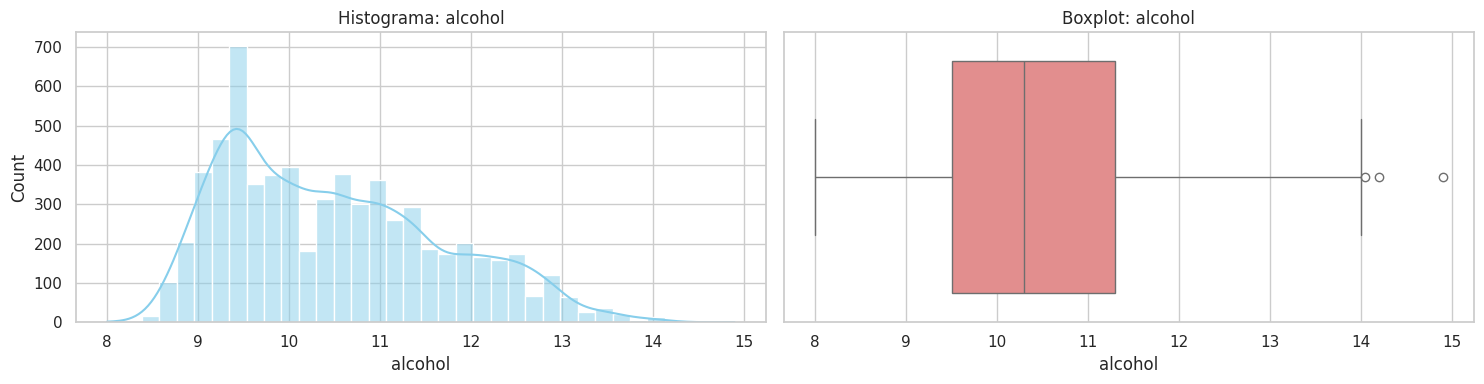

In [10]:
#MILESTONE2
#Marcello Portugal e Afonso Carvalho
import matplotlib.pyplot as plt
import seaborn as sns

#Análise Univariada 
#Selecionar apenas as colunas numéricas (excluindo 'is_red' que é binária)
#Apenas foram utilizadas variaveis fisico-quimicas
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns.drop(['quality', 'is_red'], errors='ignore')

# Configurar o estilo
sns.set_theme(style="whitegrid")

# Loop para gerar os gráficos de cada variável
for col in colunas_numericas:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    
    # Histograma (Distribuição)
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histograma: {col}')
    
    # Boxplot (Outliers)
    sns.boxplot(x=df[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot: {col}')
    
    plt.tight_layout()
    plt.show()

### Tratamento por capping
Os outliers são limitados (não eliminados) aos limites do IQR.
Optámos por capping em vez de remoção para preservar todos os 6.497 registos.
A eliminação de linhas poderia agravar o desequilíbrio das notas extremas.

## 11. Verificação do encoding
Confirmação de que não existem colunas de texto residuais.
A variável categórica (tipo de vinho) já está codificada como `is_red`.

Frequência Absoluta:
 type
white    4898
red      1599
Name: count, dtype: int64

Frequência Percentual (%):
 type
white    75.388641
red      24.611359
Name: proportion, dtype: float64


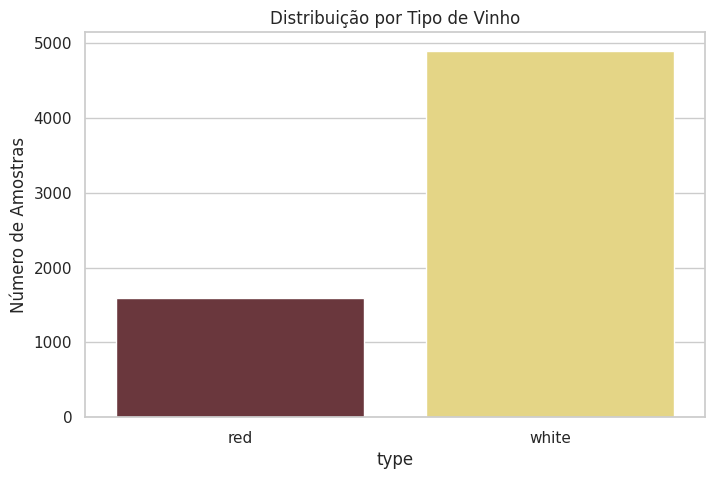

In [11]:
#MILESTONE2
#Marcello Portugal e Afonso Carvalho
#Análise Univariada
#Tabela de frequências (Absoluta e Percentual)
contagem = df['type'].value_counts()
percentagem = df['type'].value_counts(normalize=True) * 100

print("Frequência Absoluta:\n", contagem)
print("\nFrequência Percentual (%):\n", percentagem)

#Visualização com Gráfico de Barras
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='type', hue='type', palette=['#722f37', '#f4e076'], legend=False)
plt.title('Distribuição por Tipo de Vinho')
plt.ylabel('Número de Amostras')
plt.show()


## 12. Engenharia de atributos
Criação de duas variáveis derivadas com justificação enológica:
- `so2_ratio` = SO₂ livre / SO₂ total (eficiência da conservação)
- `volatile_acidity_ratio` = acidez volátil / acidez fixa (indicador de desequilíbrio)

Estes rácios captam relações entre variáveis que os modelos podem não aprender sozinhos.

### Correlação dos novos atributos com a qualidade
Verificação de que os rácios criados têm de facto relação com a variável alvo.

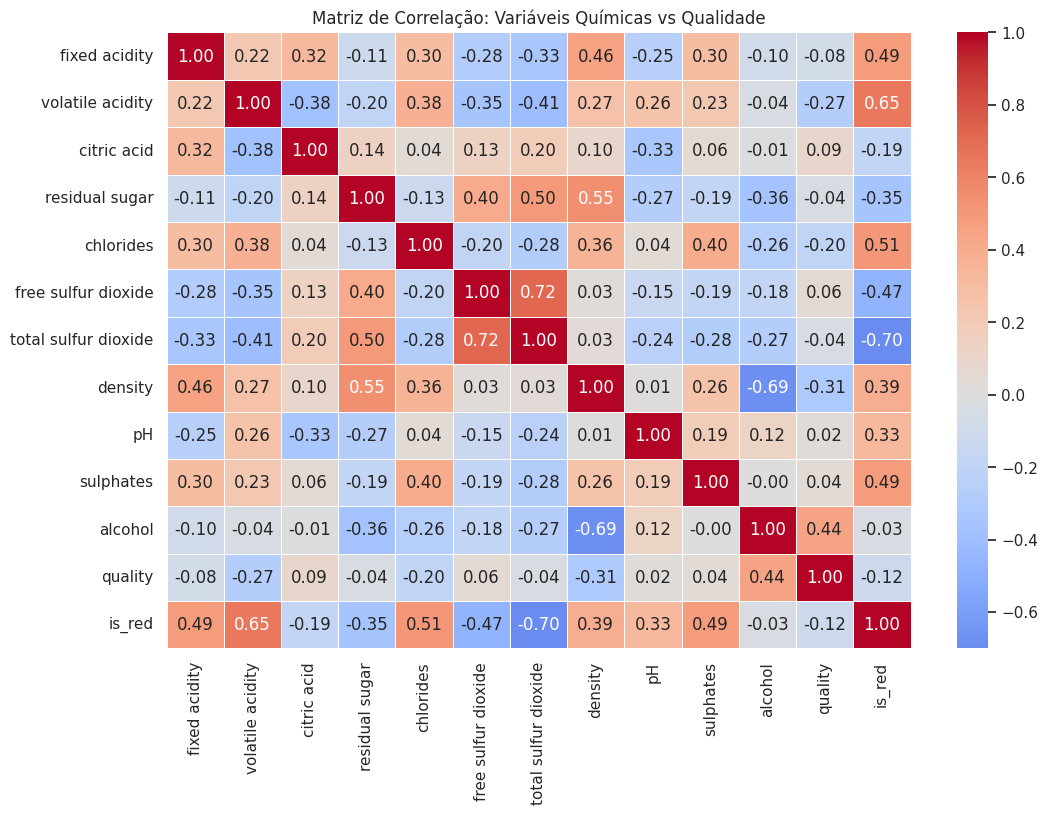

In [12]:
#Análise Bivariada e Correlações Relevantes
#Marcello Portugal e Afonso Carvalho
# Configurar o estilo visual
plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

# Selecionar apenas as colunas numéricas (incluindo is_red e quality)
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Calcular a correlação de Pearson
corr = df_numeric.corr()

# Gerar o Heatmap
sns.heatmap(corr, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0, 
            linewidths=0.5)

plt.title('Matriz de Correlação: Variáveis Químicas vs Qualidade')
plt.show()

### Heatmap: novos atributos vs qualidade
Visualização da matriz de correlação restrita aos rácios e à qualidade.

### Distribuição do rácio de acidez por nota de qualidade
Gráfico de densidade (ridgeplot) que mostra como a distribuição do rácio de acidez volátil
se desloca consoante a nota. Vinhos de qualidade superior tendem a ter rácios mais baixos.

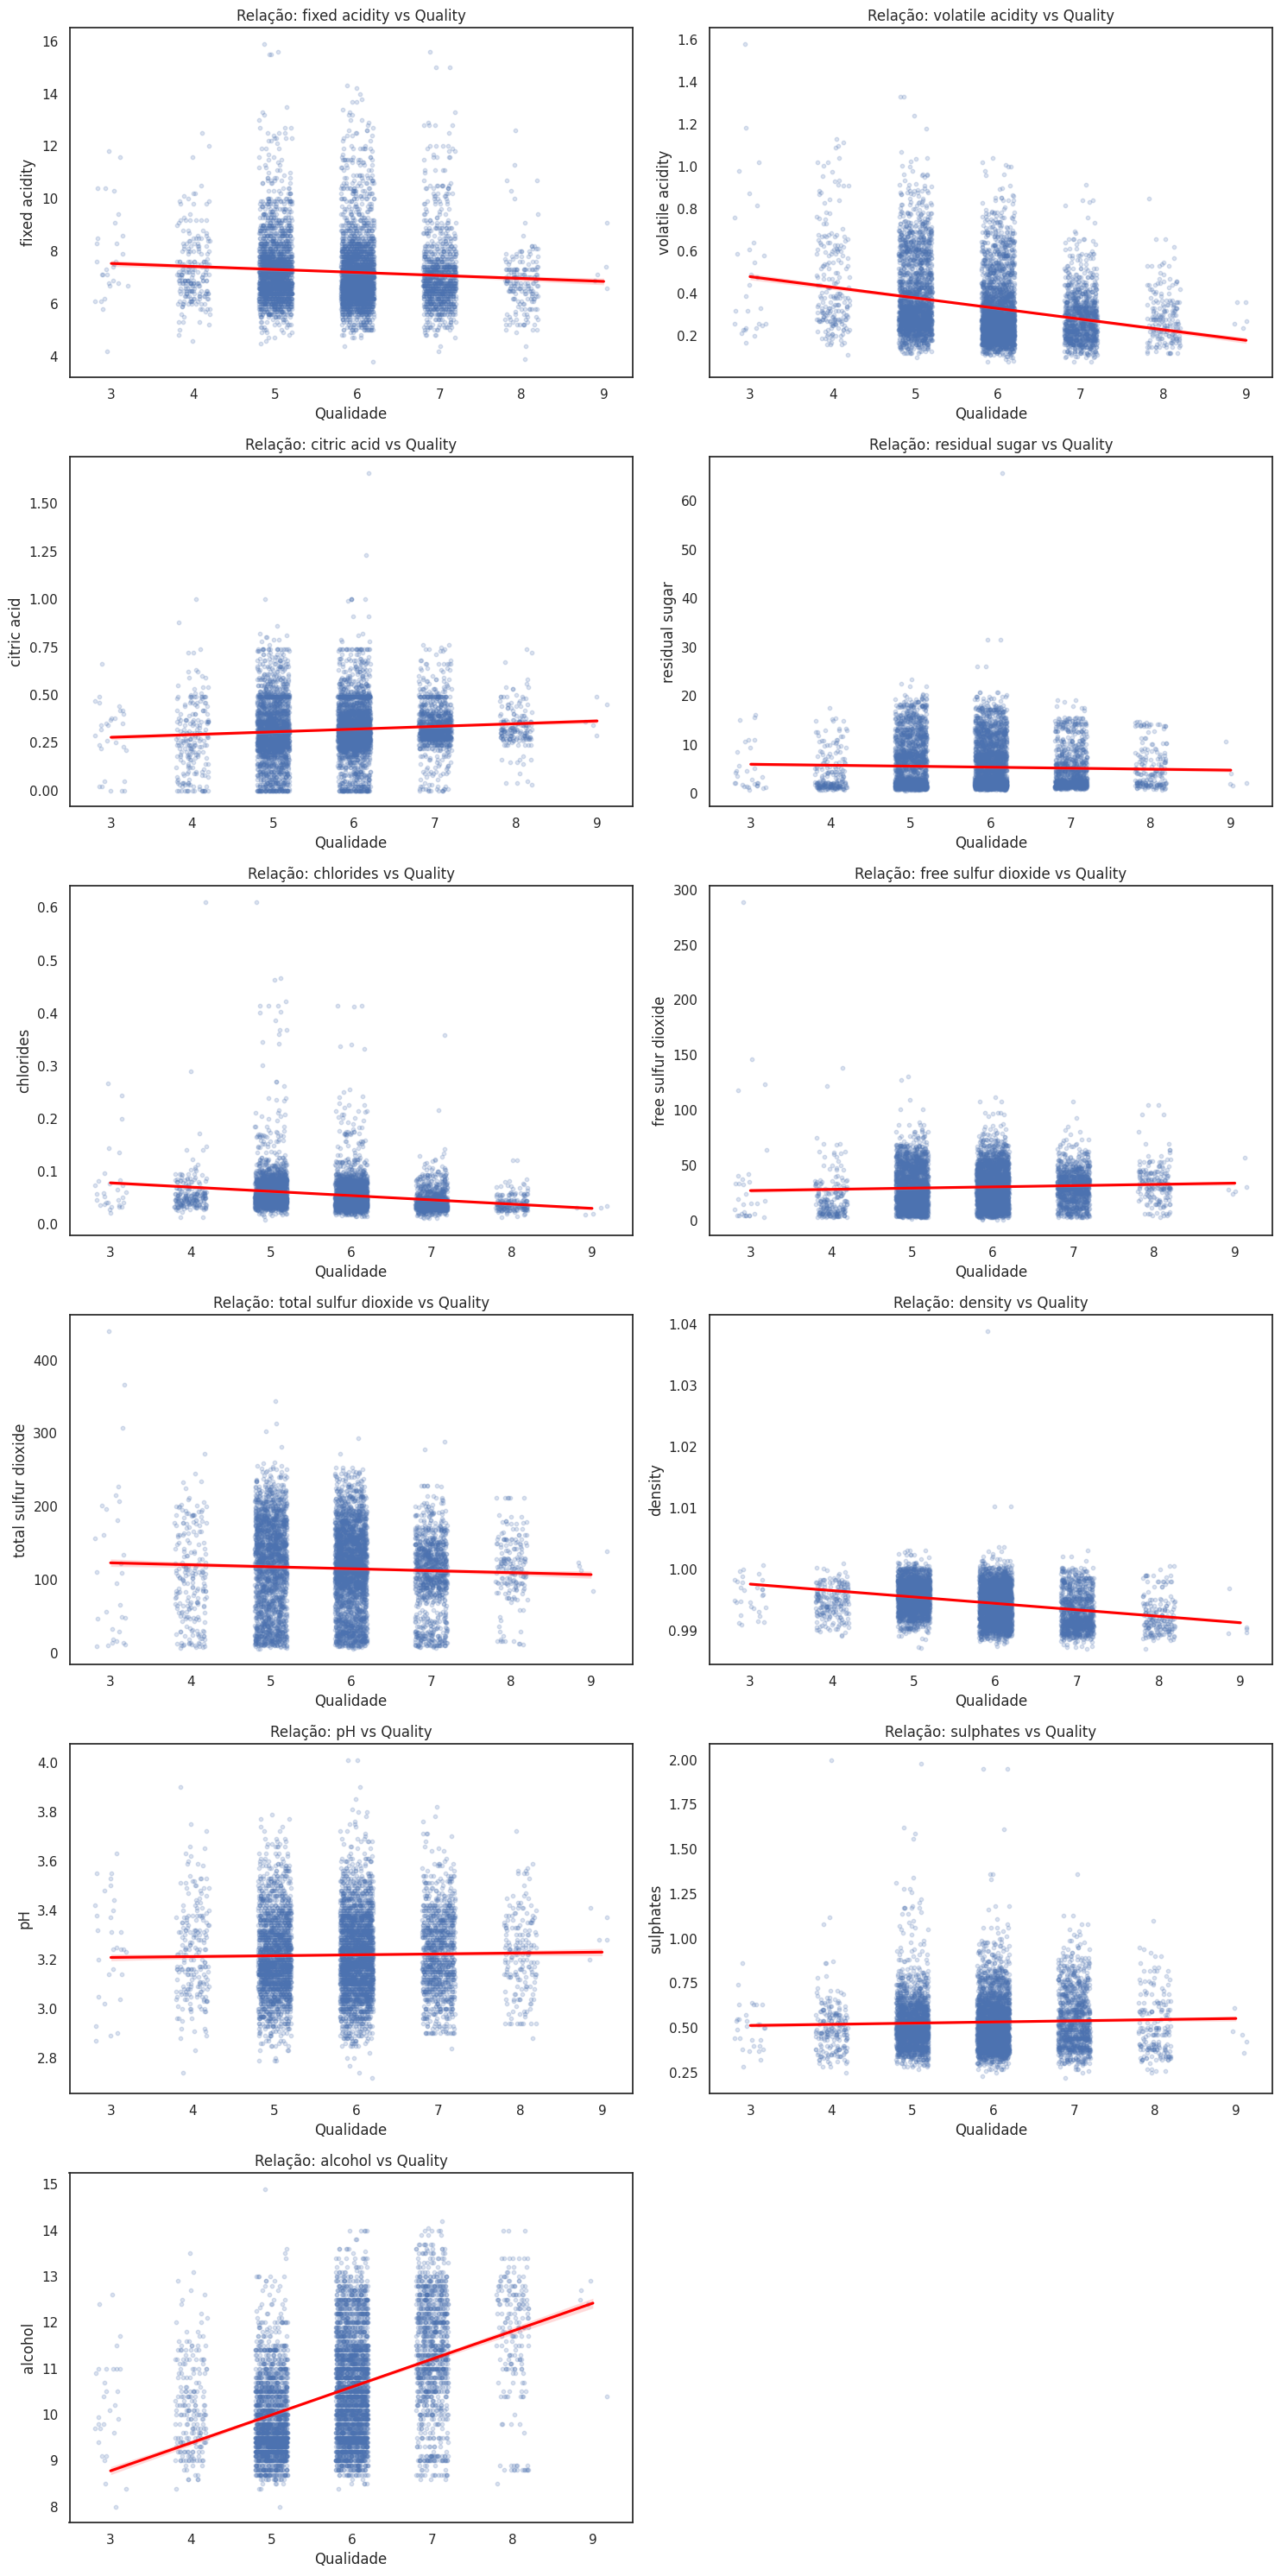

In [13]:
#Marcello Portugal e Afonso Carvalho
#Lista das 11 variáveis físico-químicas
cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
        'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
        'pH', 'sulphates', 'alcohol']

# Configurar a grelha de gráficos (6 linhas x 2 colunas para caberem as 11)
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 30))
axes = axes.flatten() # Transformar a grelha numa lista simples para o loop

for i, col in enumerate(cols):
    # sns.regplot cria o scatter plot e adiciona uma linha de tendência
    # x_jitter ajuda a ver a concentração de pontos em variáveis discretas como a quality
    sns.regplot(data=df, x='quality', y=col, ax=axes[i], 
                scatter_kws={'alpha':0.2, 's':10}, 
                line_kws={'color':'red'},
                x_jitter=0.2)
    
    axes[i].set_title(f'Relação: {col} vs Quality')
    axes[i].set_xlabel('Qualidade')
    axes[i].set_ylabel(col)

# Remover o último gráfico que fica vazio (porque temos 11 variáveis para 12 espaços)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# O QUE OBSERVAR NESTES GRÁFICOS:
# -------------------------------
# - INCLINAÇÃO DA LINHA: Se a linha sobe (ex: Alcohol), a correlação é positiva. Se desce 
#   (ex: Volatile Acidity), a correlação é negativa.
# - DENSIDADE (MANCHAS ESCURAS): A maior concentração nos valores 5 e 6 confirma o 
#   desequilíbrio da variável alvo.
# - LINHAS PLANAS: Indicam que a variável tem pouco impacto isolado na qualidade.

## 13. Identificação de multicolinearidade
Pares de variáveis com correlação absoluta superior a 0,70.
Colinearidade não afeta a Random Forest, mas é documentada para modelos alternativos.

## 14. Exportação do dataset final
Remoção da coluna `type` (texto) e das variáveis originais substituídas pelos rácios.
O ficheiro `wine_quality_model_final.csv` é o input do notebook de modelação.

In [14]:
#Marcello Portugal e Afonso Carvalho
# Mostra os coeficientes de correlação (r) ordenados, apenas para a variável alvo
correlacoes_quality = df.select_dtypes(include=['float64', 'int64']).corr()['quality'].sort_values(ascending=False)
print("Coeficientes de Correlação (r) em relação à Qualidade:")
print(correlacoes_quality)

Coeficientes de Correlação (r) em relação à Qualidade:
quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
is_red                 -0.119323
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


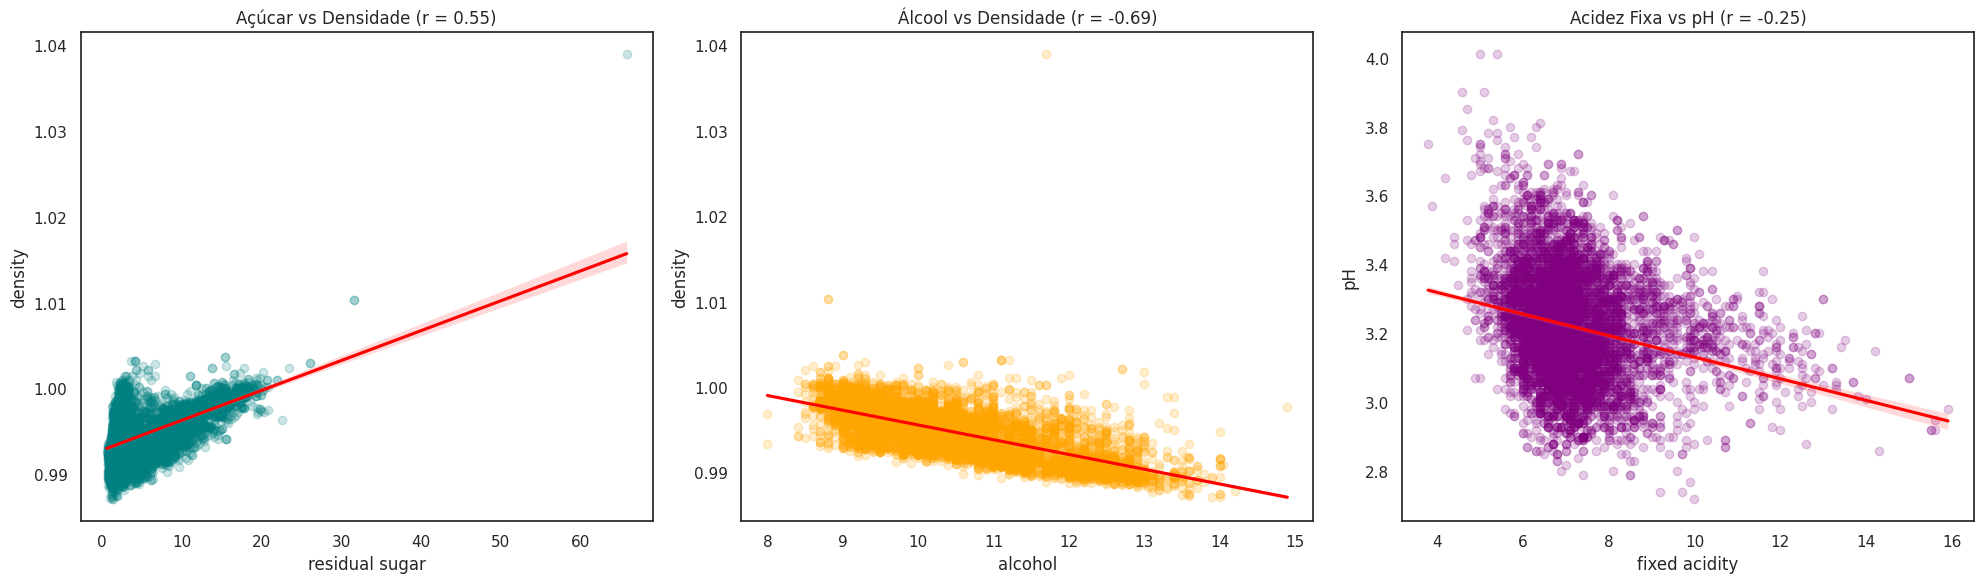

In [15]:
#Marcello Portugal e Afonso Carvalho
#COLINEARIDADE ENTRE VARIÁVEIS
#Nesta etapa analisamos como se relacionam as variáveis químicas que apresentam as principais relações entre si
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Açúcar Residual vs Densidade
# ESCOLHA: Quimicamente, o açúcar aumenta a massa do vinho sem aumentar muito o volume,
# tornando-o mais denso. Esperamos uma correlação positiva muito forte.
r1 = df['residual sugar'].corr(df['density'])
sns.regplot(data=df, x='residual sugar', y='density', ax=axes[0], 
            scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'red'})
axes[0].set_title(f'Açúcar vs Densidade (r = {r1:.2f})')

# 2. Álcool vs Densidade
# ESCOLHA: O álcool é menos denso que a água. Portanto, vinhos com maior teor alcoólico 
# tendem a ser menos densos. Esperamos uma correlação negativa.
r2 = df['alcohol'].corr(df['density'])
sns.regplot(data=df, x='alcohol', y='density', ax=axes[1], 
            scatter_kws={'alpha':0.2, 'color':'orange'}, line_kws={'color':'red'})
axes[1].set_title(f'Álcool vs Densidade (r = {r2:.2f})')

# 3. Acidez Fixa vs pH
# ESCOLHA: O pH é uma medida inversa da concentração de iões de hidrogénio. 
# Quanto mais ácidos (fixed acidity) o vinho tiver, menor deve ser o seu pH.
r3 = df['fixed acidity'].corr(df['pH'])
sns.regplot(data=df, x='fixed acidity', y='pH', ax=axes[2], 
            scatter_kws={'alpha':0.2, 'color':'purple'}, line_kws={'color':'red'})
axes[2].set_title(f'Acidez Fixa vs pH (r = {r3:.2f})')

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Marcello Portugal e Afonso Carvalho
# MILESTONE 2
# 2.1. IDENTIFICAÇÃO DE VALORES NULOS (MISSING VALUES)


# 1. Calcular a contagem absoluta e a percentagem de valores nulos
total_nulos = df.isnull().sum()
percentagem_nulos = (df.isnull().sum() / len(df)) * 100

# 2. Criar um DataFrame resumo para facilitar a leitura
resumo_nulos = pd.DataFrame({
    'Total de Nulos': total_nulos, 
    'Percentagem (%)': percentagem_nulos
})

# Ordenar do maior para o menor número de nulos
resumo_nulos = resumo_nulos.sort_values(by='Total de Nulos', ascending=False)

print("--- Resumo de Valores Nulos por Coluna ---")
print(resumo_nulos)

--- Resumo de Valores Nulos por Coluna ---
                      Total de Nulos  Percentagem (%)
fixed acidity                      0              0.0
volatile acidity                   0              0.0
citric acid                        0              0.0
residual sugar                     0              0.0
chlorides                          0              0.0
free sulfur dioxide                0              0.0
total sulfur dioxide               0              0.0
density                            0              0.0
pH                                 0              0.0
sulphates                          0              0.0
alcohol                            0              0.0
quality                            0              0.0
type                               0              0.0
is_red                             0              0.0


In [17]:
import pandas as pd
import numpy as np

#Afonso Carvalho e Marcello Portugal
#Validação e Correção de Tipos de Dados

# 1. Isolar as propriedades químicas do vinho (excluindo nota de qualidade e tipo de vinho)
colunas_quimicas = df.columns.drop(['quality', 'type', 'is_red']) 

#2.  Forçar a conversão para garantir que medições químicas (ex: pH ou densidade) não são lidas como texto
for col in colunas_quimicas:
    df[col] = pd.to_numeric(df[col], errors='coerce') 

#3.  Verificar se havia letras ou erros de digitação escondidos nos dados químicos
print("--- Novos nulos gerados após conversão das propriedades químicas ---")
print(df[colunas_quimicas].isnull().sum())


--- Novos nulos gerados após conversão das propriedades químicas ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64


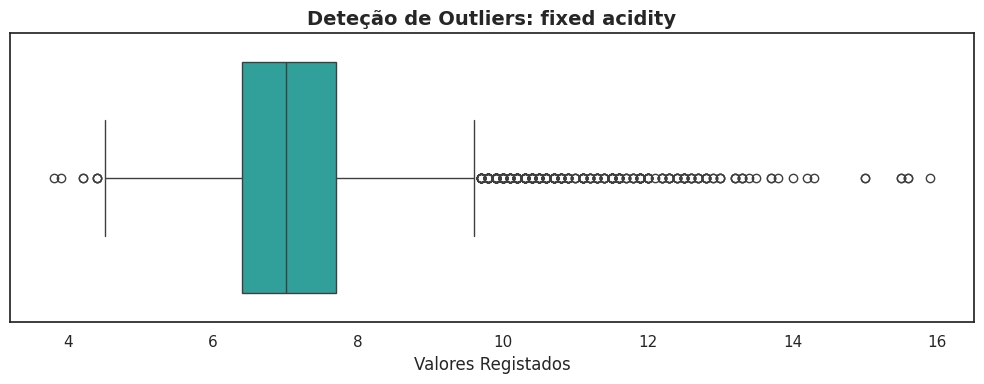

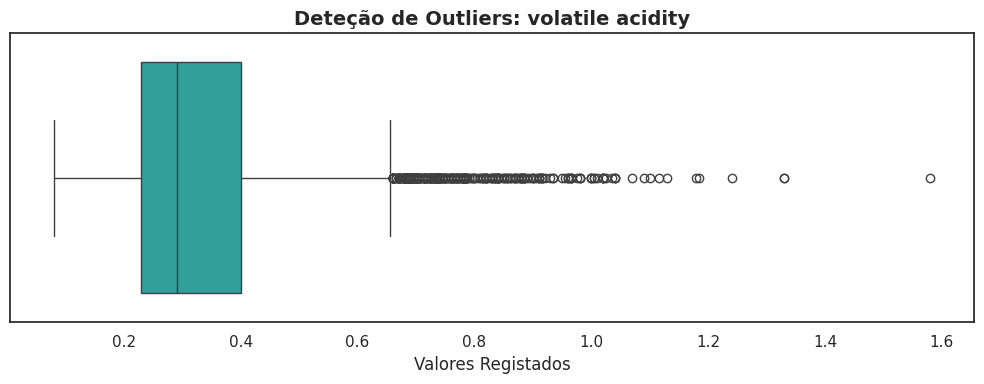

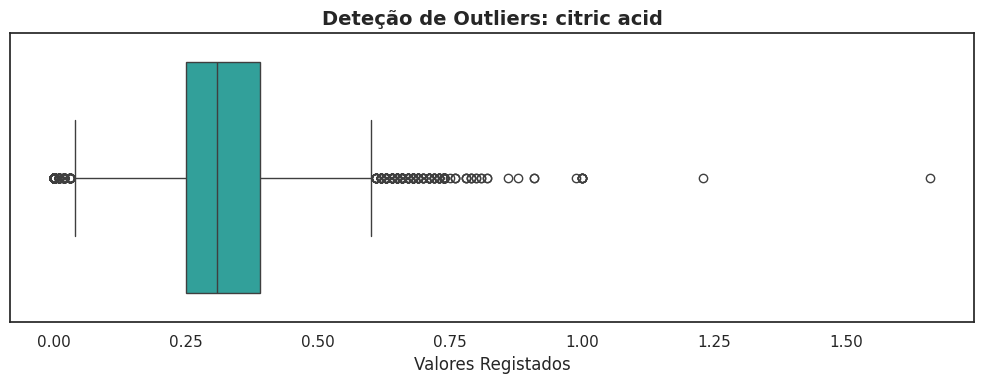

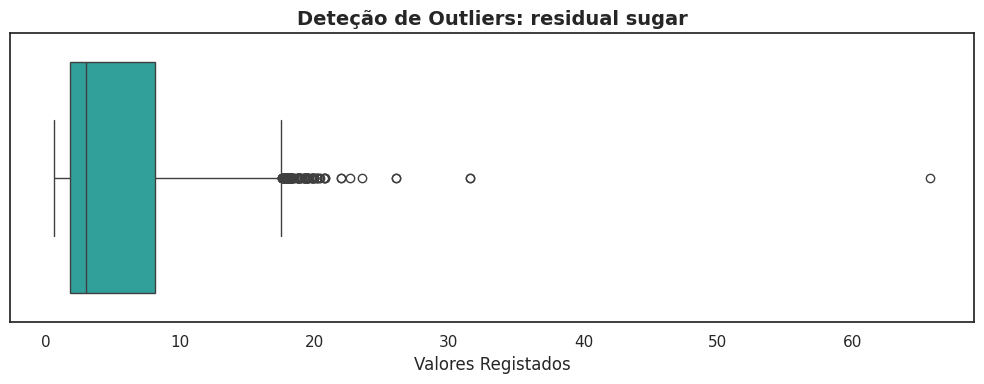

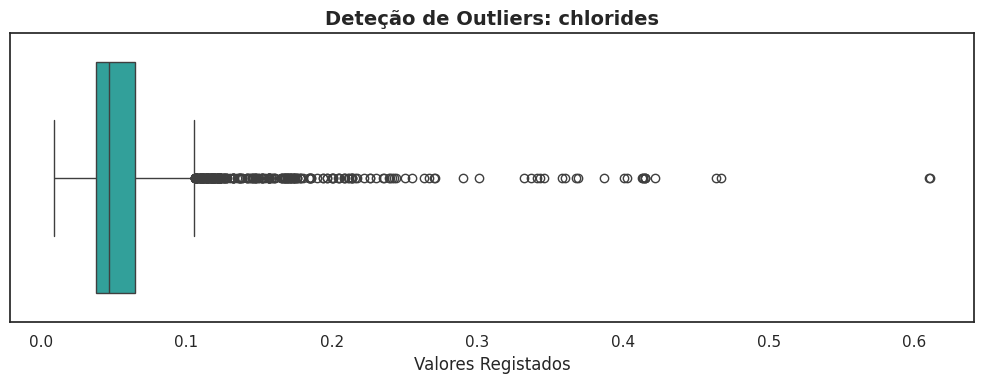

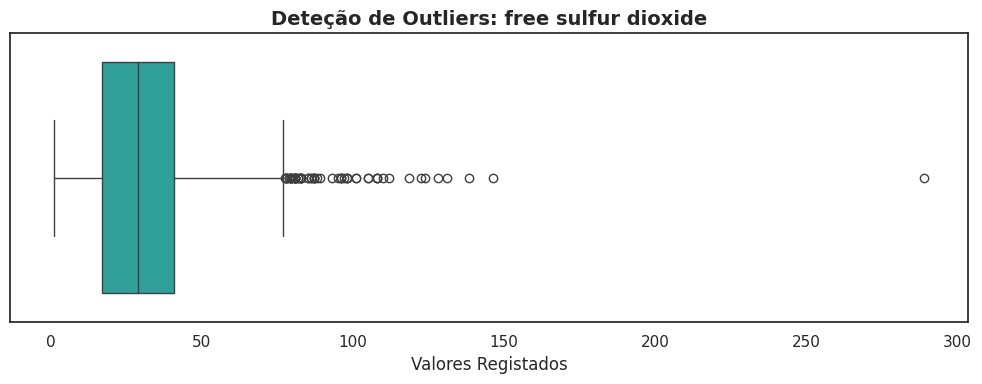

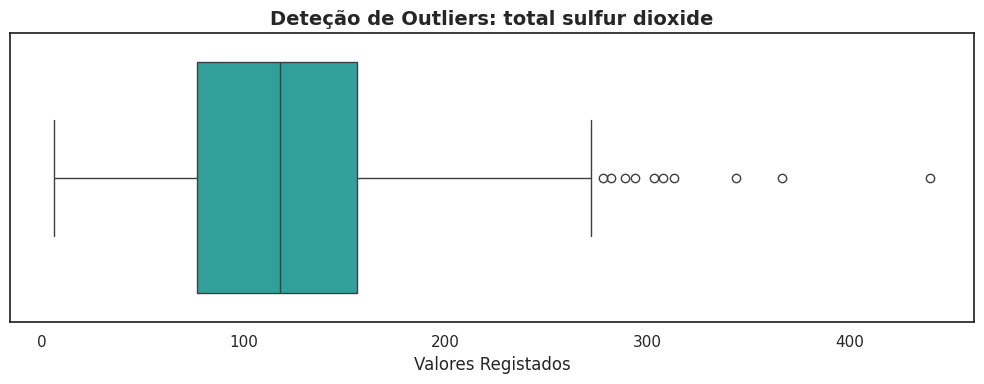

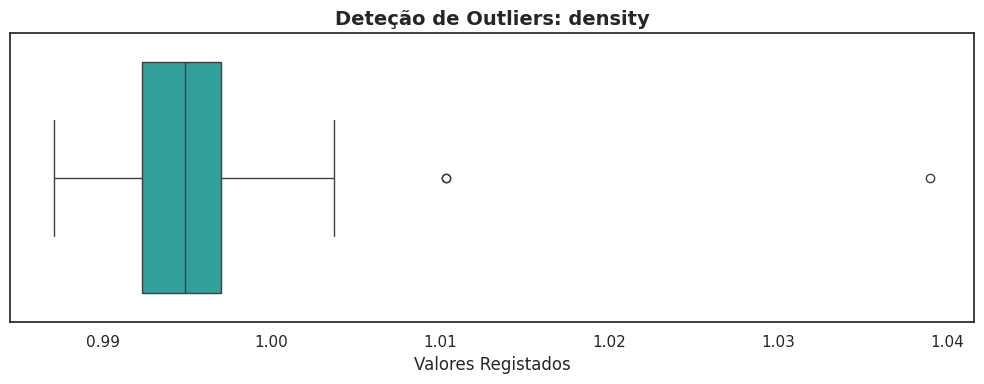

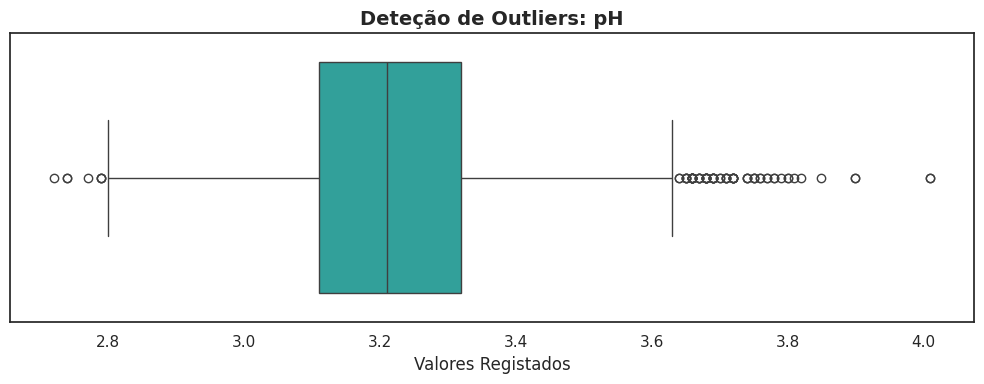

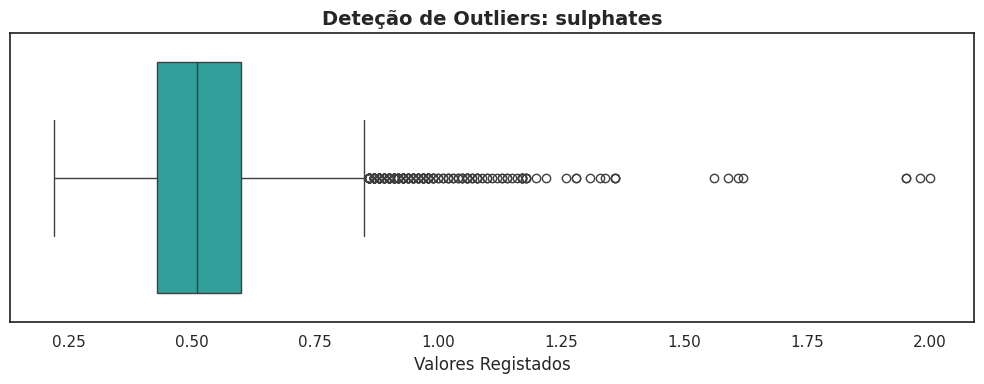

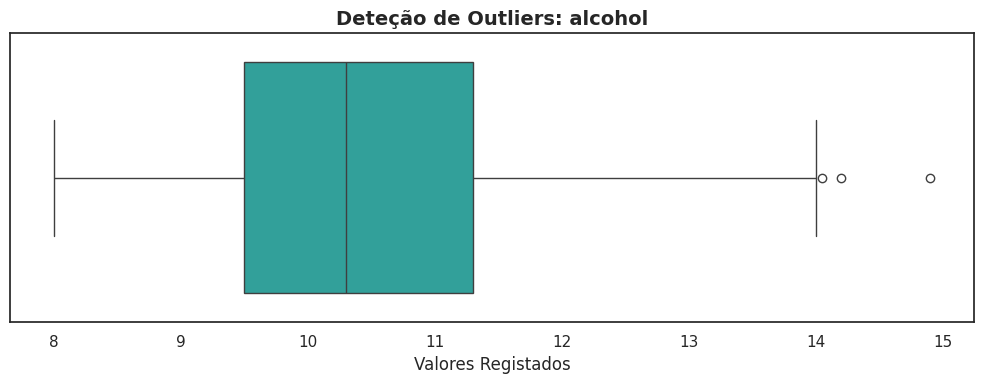

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

#Afonso Carvalho e Marcello Portugal
#Análise Visual de Outliers (Boxplots)

#1.  Gerar Boxplots horizontais para detetar picos nas propriedades químicas dos vinhos (ex: excesso de açúcar ou cloretos)
for col in colunas_quimicas:
    plt.figure(figsize=(10, 4)) 
    sns.boxplot(x=df[col], color='lightseagreen') 
    
    # 2. Adicionar título dinâmico para cada propriedade enológica e apresentar o gráfico
    plt.title(f'Deteção de Outliers: {col}', fontsize=14, fontweight='bold')
    plt.xlabel('Valores Registados', fontsize=12)
    plt.tight_layout()
    plt.show()

In [19]:
#Afonso Carvalho e Marcello Portugal
#Contagem Estatística de Outliers (Método IQR)

# 1. Contabilizar o número exato de vinhos com propriedades químicas fora do normal (Método IQR)
print("\n--- CONTAGEM DE OUTLIERS (MÉTODO IQR) ---")
outliers_totais = 0

for col in colunas_quimicas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1 
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # 2. Encontrar os vinhos que ultrapassam as fronteiras químicas e somar à contagem
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    quantidade = len(outliers)
    outliers_totais += quantidade
    print(f"{col}: {quantidade} vinhos atípicos")

# 3. Mostrar o total de anomalias encontradas nas 6497 amostras
print(f"\nTotal de anomalias detetadas no dataset inteiro: {outliers_totais}")


--- CONTAGEM DE OUTLIERS (MÉTODO IQR) ---
fixed acidity: 357 vinhos atípicos
volatile acidity: 377 vinhos atípicos
citric acid: 509 vinhos atípicos
residual sugar: 118 vinhos atípicos
chlorides: 286 vinhos atípicos
free sulfur dioxide: 62 vinhos atípicos
total sulfur dioxide: 10 vinhos atípicos
density: 3 vinhos atípicos
pH: 73 vinhos atípicos
sulphates: 191 vinhos atípicos
alcohol: 3 vinhos atípicos

Total de anomalias detetadas no dataset inteiro: 1989


In [20]:
#Afonso Carvalho e Marcello Portugal
#Tratamento de Outliers (Técnica de Capping)

# 1. Limitar os valores extremos sem apagar os vinhos reais do dataset (Técnica de Capping)
print("\n--- APLICAR TRATAMENTO DE OUTLIERS (CAPPING) ---")

for col in colunas_quimicas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    #2.  "Esmagar" os picos químicos extremos (ex: níveis de cloretos absurdos) para os limites normais
    df[col] = df[col].clip(lower=limite_inferior, upper=limite_superior)

# 3. Confirmar que preservámos todos os vinhos após a correção química
print("Tratamento concluído: Todos os valores atípicos foram limitados às fronteiras normais.")
print(f"Total de vinhos preservados no dataset: {len(df)}")


--- APLICAR TRATAMENTO DE OUTLIERS (CAPPING) ---
Tratamento concluído: Todos os valores atípicos foram limitados às fronteiras normais.
Total de vinhos preservados no dataset: 6497


In [21]:

#Afonso Carvalho e Marcello Portugal
# VERIFICAÇÃO DO ENCODING
print("--- VERIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS ---")

# Como criámos a coluna 'is_red' (0 e 1) no início do projeto, o Encoding já está feito.
# Vamos apenas confirmar que o dataset não tem colunas de texto (object) a estorvar.
tipos_de_dados = df.dtypes
colunas_texto = tipos_de_dados[tipos_de_dados == 'object']

if len(colunas_texto) == 0:
    print("Sucesso: Não existem colunas de texto. A variável categórica do tipo de vinho já está codificada numericamente ('is_red').")
    print("O dataset está pronto para o escalonamento.")
else:
    print(f"Atenção, ainda existem colunas de texto: {colunas_texto.index.tolist()}")

--- VERIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS ---
Sucesso: Não existem colunas de texto. A variável categórica do tipo de vinho já está codificada numericamente ('is_red').
O dataset está pronto para o escalonamento.


In [22]:
#Afonso Carvalho e Marcello Portugal
#  Criação das novas variáveis

# 1. Rácio de Dióxido de Enxofre (Eficiência da conservação)
df['so2_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']

# 2. Rácio de Acidez Volátil (Indicador de desequilíbrio)
df['volatile_acidity_ratio'] = df['volatile acidity'] / df['fixed acidity']

# 3. Mostrar as primeiras linhas para confirmar que as colunas foram criadas corretamente
display(df[['free sulfur dioxide', 'total sulfur dioxide', 'so2_ratio', 
            'volatile acidity', 'fixed acidity', 'volatile_acidity_ratio']].head())

,free sulfur dioxide,total sulfur dioxide,so2_ratio,volatile acidity,fixed acidity,volatile_acidity_ratio
0,11.0,34.0,0.323529,0.655,7.40,0.088514
1,25.0,67.0,0.373134,0.655,7.80,0.083974
2,15.0,54.0,0.277778,0.655,7.80,0.083974
3,17.0,60.0,0.283333,0.280,9.65,0.029016
4,11.0,34.0,0.323529,0.655,7.40,0.088514


In [23]:
#Afonso Carvalho e Marcello Portugal

# 1. Verificar a correlação com a variável alvo ('quality')
correlacoes = df[['so2_ratio', 'volatile_acidity_ratio', 'quality']].corr()

# 2. Isolar e imprimir apenas a coluna da 'quality' para ver o impacto direto
print("Correlação das novas variáveis com a Qualidade:")
print(correlacoes['quality'])

Correlação das novas variáveis com a Qualidade:
so2_ratio                 0.120925
volatile_acidity_ratio   -0.221805
quality                   1.000000
Name: quality, dtype: float64


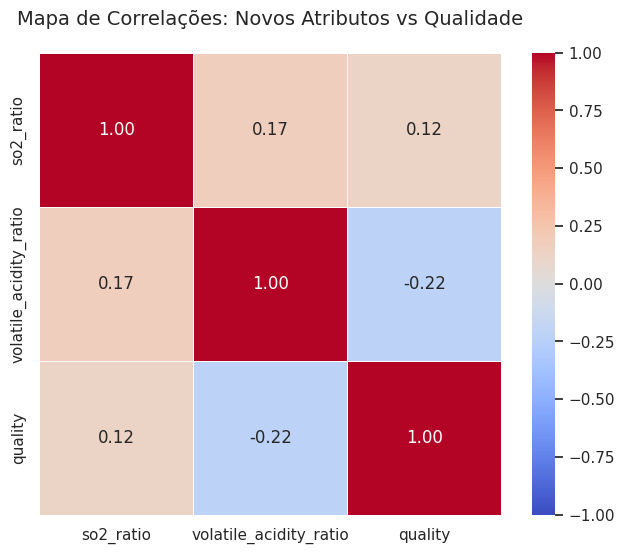

In [24]:
#Afonso Carvalho e Marcello Portugal

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selecionar apenas as colunas que importam para não poluir o gráfico
colunas_interesse = ['so2_ratio', 'volatile_acidity_ratio', 'quality']

# 2. Calcular a matriz de correlação matemática
matriz_corr = df[colunas_interesse].corr()

# 3. Desenhar o Mapa de Calor (Heatmap)
plt.figure(figsize=(8, 6))

# 4. annot=True mostra os números
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", 
            vmin=-1, vmax=1, linewidths=0.5, square=True)

plt.title('Mapa de Correlações: Novos Atributos vs Qualidade', pad=20, fontsize=14)
plt.show()

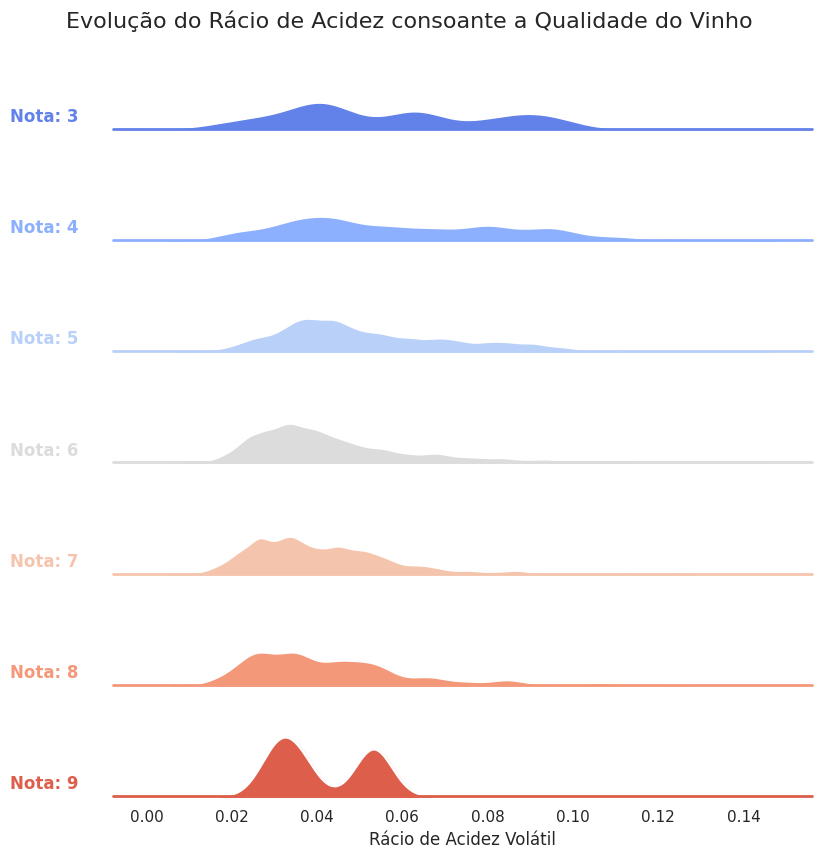

In [25]:
#Afonso Carvalho e Marcello Portugal

import seaborn as sns
import matplotlib.pyplot as plt


# 1. Preparar o estilo visual
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# 2. Criar a estrutura do gráfico (uma linha para cada nota de 'quality')
g = sns.FacetGrid(df, row="quality", hue="quality", aspect=7, height=1.2, palette="coolwarm")

# 3. Desenhar as "montanhas" (curvas de densidade)
g.map(sns.kdeplot, "volatile_acidity_ratio", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "volatile_acidity_ratio", clip_on=False, color="w", lw=2, bw_adjust=.5)
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# 4. Função para escrever a nota de Qualidade ao lado de cada montanha
def adicionar_rotulo(x, color, label):
    ax = plt.gca()
    # Escreve "Nota: X" no lado esquerdo de cada linha
    ax.text(-0.05, 0.2, f"Nota: {label}", fontweight="bold", color=color,
            ha="right", va="center", transform=ax.transAxes)

# Aplicar a função aos nossos dados
g.map(adicionar_rotulo, "volatile_acidity_ratio")

# 5. Limpar os eixos antigos e colocar o título final
g.set_titles("")
g.set(yticks=[], ylabel="") # Escondemos o eixo Y padrão porque já criámos os nossos rótulos acima
g.despine(bottom=True, left=True)

plt.suptitle('Evolução do Rácio de Acidez consoante a Qualidade do Vinho', y=1.02, fontsize=16)
plt.xlabel('Rácio de Acidez Volátil')
plt.show()

In [26]:
# Afonso Carvalho e Marcello Portugal
# Identificação de Multicolinearidade

# 1. Selecionar apenas colunas com números (ignora as de texto)
df_numerico = df.select_dtypes(include=[np.number])

# 2. Calcular a matriz de correlação removendo a variavel alvo
if 'quality' in df_numerico.columns:
    df_numerico = df_numerico.drop('quality', axis=1)

corr_matrix = df_numerico.corr().abs()

# 3. Transformar a matriz numa lista de pares
matriz_empilhada = corr_matrix.unstack()

# 4. Remover as correlações da variável com ela própria (1.0)
matriz_empilhada = matriz_empilhada[matriz_empilhada != 1.0]

# 5. Filtrar as correlações fortes (> 0.70) e remover duplicados
pares_fortes = matriz_empilhada[matriz_empilhada > 0.70].drop_duplicates()

print("Pares de variáveis com alerta de Multicolinearidade (>0.70):")
print(pares_fortes.sort_values(ascending=False))

Pares de variáveis com alerta de Multicolinearidade (>0.70):
volatile acidity      volatile_acidity_ratio    0.924435
free sulfur dioxide   total sulfur dioxide      0.731636
chlorides             is_red                    0.715957
total sulfur dioxide  is_red                    0.703041
density               alcohol                   0.701297
dtype: float64


In [27]:
# Limpeza Final e Exportação do Dataset

# 1. Remover a coluna de texto ('type') e as colunas originais que substituímos pelos rácios
df_final = df.drop(columns=['type', 'volatile acidity', 'free sulfur dioxide'])

# 2. Exportar o dataset final limpo e pronto para a Fase 3
df_final.to_csv('wine_quality_model_final.csv', index=False)

print(f"Sucesso! O ficheiro 'wine_quality_model_ready.csv' foi guardado com {df_final.shape[1]} colunas.")

Sucesso! O ficheiro 'wine_quality_model_ready.csv' foi guardado com 13 colunas.
